<div style="background-color:#EAEAEA;padding:20px;border-left:5px solid #6C757D;border-radius:6px;">
<table style="width:100%; border:none;"><tr style="border:none;">
<td style="border:none; vertical-align:top;">
<h1 style="font-size:32px; margin-top:0;">Master's Thesis</h1>
<hr style="margin:16px 0 22px 0;">
<p style="font-size:22px; line-height:1.5; margin:0;"><strong>Master's Degree in Advanced Physics</strong> - <strong>Universitat de Valencia</strong></p>
<p style="font-size:17px; margin-top:28px; margin-bottom:6px;">This notebook is part of the <strong>Master's Thesis (MSc Dissertation)</strong>:</p>
<div style="font-size:25px;font-weight:700;line-height:1.3;margin-top:14px;margin-bottom:26px;">Fast Simulation of Neutrino Oscillations in Matter</div>
<p style="font-size:14px; line-height:1.55;"><strong>Author</strong><br>Juan Ramon Diaz Santos - <a href="mailto:diazjuan@alumni.uv.es">diazjuan@alumni.uv.es</a></p>
<p style="font-size:14px; line-height:1.55;"><strong>Supervisors</strong><br>Roberto Ruiz de Austri Bazan - <a href="mailto:rruiz@ific.uv.es">rruiz@ific.uv.es</a><br>Michele Lucente - <a href="mailto:michele.lucente@unibo.it">michele.lucente@unibo.it</a></p>
<p style="font-size:14px; line-height:1.55; margin-bottom:0;"><strong>Date</strong><br>September 2026</p></td>
<td style="border:none;width:230px;padding-left:25px;text-align:right;vertical-align:top;"><img src="../logo_uv.png" alt="Universitat de Valencia" style="width:200px; margin-top:5px;"></td>
</tr></table></div>

# Inference 5 -- IceCube DeepCore: Fitting Atmospheric Oscillations to Real Weighted Monte Carlo
---
Fits the atmospheric mixing angle $\theta_{23}$ and mass splitting $\Delta m^2_{3l}$ to the real IceCube DeepCore "9-year golden event" public data release, using `tpeanuts`'s own differentiable 3-flavour Earth-matter propagation and a real event-by-event Monte-Carlo reweighting forward model (Section 0). Every number, formula, and citation needed to follow this notebook is contained in it -- it has no hidden execution-state dependencies.

---

## Table of Contents

| # | Section |
|---|---|
| [0](#0.-Theoretical-Framework) | **Theoretical Framework** |
| [1](#1.-Libraries) | **Libraries** |
| [2](#2.-Paths-and-Configuration) | **Paths and Configuration** |
| [3](#3.-Gradient-Check) | **Gradient Check** |
| [4](#4.-tpeanuts-Simulation-at-NuFit-6.1----Normalization-Calibration) | **tpeanuts Simulation at NuFit 6.1 -- Normalization Calibration** |
| [5](#5.-Real-Poisson-Fit) | **Real Poisson Fit** |
| [6](#6.-Real-Data-Comparison) | **Real Data Comparison** |
| [7](#7.-Summary) | **Summary** |


## 0. Theoretical Framework

This stage evaluates theoretical framework with the likelihood, physical priors, covariance model, and numerical controls defined above.


### 0.1 Real Weighted Monte Carlo Reweighting

The IceCube DeepCore public data release [1] does not provide a differential cross section: it provides $\sim$400,000 individually simulated events, each carrying its **true** (simulated) energy $E_i$, cosine of zenith angle $\cos\theta_{z,i}$, and flavour/reaction ($\alpha_i\to\beta_i$, from its PDG code and reaction file), its **reconstructed** analysis-bin location, and a real physical weight $w_i$ (units GeV cm$^2$ sr). The release's own documentation states that $w_i$ must be multiplied by the atmospheric flux (cm$^{-2}$ s$^{-1}$ sr$^{-1}$ GeV$^{-1}$) and by a livetime (s) to become a physical event count -- the standard "weighted Monte Carlo" technique used throughout atmospheric-neutrino oscillation analyses.

For an event whose PDG code/reaction file tags it as flavour $\beta_i$ at the interaction point (this applies identically to neutral-current and charged-current events: an NC interaction still requires the neutrino to *be* flavour $\beta_i$ at that point), the physically correct expectation sums over every possible parent flavour $\alpha$ at production, weighted by the real unoscillated atmospheric flux $\Phi_\alpha$ and the oscillation transition probability $P(\nu_\alpha\to\nu_{\beta_i})$:

$$N_i(\theta) = \nu_{\rm norm}\cdot w_i \sum_{\alpha\in\{e,\mu\}} \Phi_\alpha\!\left(E_i,\cos\theta_{z,i}\right)\, P\!\left(\nu_\alpha\to\nu_{\beta_i};\,E_i,\cos\theta_{z,i};\,\theta\right),$$

where $\theta=(\theta_{23},\Delta m^2_{3l})$ are the two oscillation parameters being fit, and $\nu_{\rm norm}$ is a free overall normalization (Section 0.3 -- the release states no absolute livetime usable on its own). The sum runs over $\alpha\in\{e,\mu\}$ only: the primary/conventional atmospheric $\nu_\tau$ flux is negligible at these energies, so no tau-flavour parent term is needed (and the real flux table used here, Section 0.3, has no $\nu_\tau$ entry either). Every simulated event in a given real analysis bin $k$ is summed to give that bin's predicted neutrino count,

$$N_k^{\nu}(\theta) = \sum_{i\,\in\,{\rm bin}\,k} N_i(\theta).$$


### 0.2 Real 3-Flavour Neutrino Oscillations in Earth Matter

A flavour state obeys $i\,d\psi/dx = H_f(x)\psi$, with the Standard-Model flavour Hamiltonian

$$H_f(x) = \frac{1}{2E}U\,{\rm diag}(0,\Delta m^2_{21},\Delta m^2_{31})\,U^\dagger + V_{\rm CC}(x)P_e,\qquad P_e={\rm diag}(1,0,0),\qquad V_{\rm CC}(x)=\sqrt{2}\,G_F\,n_e(x),$$

$U$ the PMNS matrix and $V_{\rm CC}$ the Wolfenstein charged-current matter potential [2], sourced by the Earth's electron density $n_e(x)$ along the neutrino's path. The exact evolution operator is the path-ordered exponential $S(x_2,x_1)=\mathcal T\exp\!\big[-i\!\int_{x_1}^{x_2}\!H_f(x)\,dx\big]$; `tpeanuts` evaluates it with a first-order perturbative expansion around each traversed layer's mean density (exact for the constant-density term, a Dyson correction for the layer's density residual [3]), the same construction used for every Earth-matter effect in this project.

**Geometry.** IceCube DeepCore's real analysis bins cover $\cos\theta_z\in[-1,\,0.1]$: upgoing ($\cos\theta_z=-1$, the neutrino crosses the full Earth) to just past horizontal ($\cos\theta_z=0.1$). This notebook maps the real reconstructed/true cos(zenith) to a detector nadir angle $\eta\in[0,\pi]$ via

$$\eta = \arccos(-\cos\theta_z),$$

so that $\cos\theta_z=-1\Rightarrow\eta=0$ (straight through the Earth's centre) and $\cos\theta_z=+1\Rightarrow\eta=\pi$ (directly overhead, no Earth crossing); $\eta<\pi/2$ is Earth-crossing, matching the real geometry of an upgoing atmospheric neutrino as seen from a detector at the Earth's surface. Production is treated as occurring at the top of the atmosphere directly above the entry point ($\sim$20 km, a $<0.3\%$ correction relative to the Earth's 6371 km radius) -- a real, but sub-percent-level, simplification.

**Transition probability.** With $S\equiv S_{\rm Earth}(\eta,E;\theta)$ the real 3-flavour Earth evolution operator built from $H_f$ above,

$$P(\nu_\alpha\to\nu_\beta;\,E,\eta;\,\theta) = \big|S_{\beta\alpha}(\eta,E;\theta)\big|^2.$$

Only $\theta_{23}$ and $\Delta m^2_{3l}\equiv m_3^2-m_1^2$ (normal ordering) are free in this notebook; $\theta_{12}$, $\theta_{13}$, $\Delta m^2_{21}$, and the CP phase $\delta$ are held fixed at their real NuFIT 6.1 [6] values (Section 2) -- the standard treatment in every published atmospheric-neutrino oscillation analysis, since $\theta_{23}$/$\Delta m^2_{3l}$ overwhelmingly dominate the atmospheric $\nu_\mu$ disappearance/$\nu_\tau$ appearance signal.


### 0.3 Real Atmospheric Flux and Detector-Systematics Corrections

$\Phi_\alpha(E,\cos\theta_z)$ (neutrino or antineutrino, matching each event's own PDG sign) is the real 3-dimensional Honda atmospheric flux calculation [5], azimuth-averaged (IceCube DeepCore's public binning has no azimuth axis) and bilinearly interpolated in $(\log_{10}E,\cos\theta_z)$ at each event's own true kinematics -- a fixed input, independent of $\theta$.

The release additionally provides real per-bin "hypersurface" corrections for 5 detector-calibration parameters $p_n$ (DOM efficiency, hole-ice $p_0$/$p_1$, bulk-ice absorption/scattering), tabulated at 20 real $\Delta m^2_{31}$ slices (event migration between reconstructed bins itself depends weakly on the assumed $\Delta m^2_{31}$). At a fixed systematics point $\{p_n\}$ (this notebook uses the real published best-fit point, Section 2 -- the 5 parameters are not themselves re-fit here), the per-bin correction factor is

$$C_k(p_1,\dots,p_5) = c_k + \sum_{n=1}^{5} m_{k,n}\,(p_n - p_n^{\rm nominal}),$$

with $c_k$/$m_{k,n}$ the release's own real tabulated intercept/slopes, piecewise-linearly interpolated (differentiably, in $\Delta m^2_{3l}$) between the two tabulated $\Delta m^2_{31}$ slices bracketing the fitted value. The real pre-binned atmospheric-muon background $N_k^{\mu,{\rm MC}}$ (mis-reconstructed cosmic-ray muons) is added with its own free normalization $\mu_{\rm norm}$, giving the full per-bin prediction

$$N_k(\theta,\nu_{\rm norm},\mu_{\rm norm}) = \nu_{\rm norm}\cdot N_k^\nu(\theta)\cdot C_k(\Delta m^2_{3l}) \;+\; \mu_{\rm norm}\cdot N_k^{\mu,{\rm MC}}.$$


### 0.4 Fit Statistic

Real observed counts $n_k^{\rm obs}$ are compared to $N_k(\theta,\nu_{\rm norm},\mu_{\rm norm})$ via the Poisson (Baker-Cousins) likelihood ratio [7],

$$-2\ln L = 2\sum_k\Big[N_k - n_k^{\rm obs} + n_k^{\rm obs}\ln\frac{n_k^{\rm obs}}{N_k}\Big],$$

minimized over the full 4-parameter vector $\theta_{\rm fit}=(\theta_{23},\Delta m^2_{3l},\nu_{\rm norm},\mu_{\rm norm})$ with `torch.optim.LBFGS`, using the exact autograd gradient of $-2\ln L$ through every step of Sections 0.1-0.3 (no finite differences). The marginal uncertainty on each fitted parameter is the Laplace/Fisher approximation: with $\mathcal I = \tfrac12\,\nabla^2_\theta(-2\ln L)$ the Fisher information evaluated at the optimum (autograd Hessian), the covariance is $\Sigma = \mathcal I^{-1}$ and $\sigma_j=\sqrt{\Sigma_{jj}}$.

**References**

- [1] R. Abbasi et al. (IceCube Collaboration), *Measurement of atmospheric neutrino mixing with improved IceCube DeepCore calibration and data processing*, Phys. Rev. D **108**, 012014 (2023), arXiv:2304.12236.
- [2] L. Wolfenstein, *Neutrino oscillations in matter*, Phys. Rev. D **17**, 2369 (1978).
- [3] E. K. Akhmedov, M. Maltoni and A. Yu. Smirnov, *1-3 leptonic mixing and the neutrino oscillograms of the Earth*, JHEP **05**, 077 (2007), arXiv:hep-ph/0612285.
- [4] C. Giunti and C. W. Kim, *Fundamentals of Neutrino Physics and Astrophysics*, Oxford University Press (2007).
- [5] M. Honda, T. Kajita, K. Kasahara and S. Midorikawa, *Atmospheric neutrino flux calculation using the NRLMSISE-00 atmospheric model*, Phys. Rev. D **92**, 023004 (2015), arXiv:1502.03916.
- [6] I. Esteban et al., *NuFIT 6.1 (2025), www.nu-fit.org*; base analysis: JHEP **12**, 216 (2024), arXiv:2410.05380.
- [7] S. Baker and R. D. Cousins, *Clarification of the use of chi-square and likelihood functions in fits to histograms*, Nucl. Instrum. Meth. **221**, 437 (1984).


## 1. Libraries

This stage evaluates libraries with the likelihood, physical priors, covariance model, and numerical controls defined above.


In [2]:
import math
import time

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import display

from tpeanuts.util.context import RuntimeContext
from tpeanuts.medium.earth.profile import build_earth_profile, EarthParameters
from tpeanuts.inference.atmospheric_model import AtmosphericOscillationModel
from tpeanuts.detector.icecube.inference_model import IceCubeDetectorModel
from tpeanuts.detector.icecube.event_rate import real_observed_counts, muon_background_histogram
import tpeanuts.detector.icecube.parameters as icecube_parameters
from tpeanuts.inference.fit import fit_lbfgs
from tpeanuts.inference.likelihood import poisson_nll
from tpeanuts.inference.scan import loglik_grid
from tpeanuts.notebooks.notebookConfig import load_notebook_config
from tpeanuts.notebooks.notebooks_helper import save_and_show, to_numpy

print(f'Torch {torch.__version__}')


Torch 2.5.1+cu121


## 2. Paths and Configuration

Loads the default Earth density profile, the NuFIT 6.1 [6] oscillation preset for the four fixed parameters ($\theta_{12}$, $\theta_{13}$, $\Delta m^2_{21}$, $\delta$) and the NuFIT-6.1 starting values of the two free parameters ($\theta_{23}$, $\Delta m^2_{3l}$), and builds the real forward model from the cached IceCube DeepCore data release [1] (`data/detector/icecube/raw/`) -- real observed counts, real event-by-event Monte Carlo (downsampled 10x for computational tractability, weights rescaled to compensate so the expectation is unbiased), real muon background, and real detector-systematics hypersurfaces.

**Expected Results:**
- Real total observed counts: 21,914 (the release's own number [1], reproduced exactly regardless of any fit -- a fact about the data, not a `tpeanuts` result).
- The table below is IceCube's own published best-fit point [1] (Table III/IV), shown for later comparison only -- it is not used as a prior anywhere in this notebook's fit.


### 2.1 Paths

Repository-relative paths identify the published datasets, covariance matrices, cached model inputs, and output directory without hidden execution-state dependencies.


### 2.2 Configuration

Physical priors, differentiable model parameters, numerical precision, optimizer controls, and statistical conventions are fixed here for the complete inference.


In [3]:
config     = load_notebook_config()
# Forced CPU: small problem size, sidesteps an unrelated NVRTC/JIT toolchain issue.
ctx        = RuntimeContext.resolve("cpu", config.dtype)
OUTPUT_DIR = config.output_dir("inference", "phase1_icecube")

REFERENCE_PRESET = "_SM_NUFIT61_NO"   # NuFIT 6.1 (2025), normal ordering -- see Section 0 reference [6].
DOWNSAMPLE = 10

earth_profile = build_earth_profile(None, params=EarthParameters(), context=ctx)
osc_model, theta_ref_osc = AtmosphericOscillationModel.from_preset(REFERENCE_PRESET, context=ctx)

t0 = time.time()
model = IceCubeDetectorModel.from_real_data(osc_model, earth_profile, downsample=DOWNSAMPLE, device=ctx.device, dtype=ctx.dtype)
build_time = time.time() - t0

real_counts = real_observed_counts(device=ctx.device, dtype=ctx.dtype)
n_events_per_channel = {name: ev.true_energy_MeV.numel() for name, ev in model.channels.items()}

print(f'Output dir              : {OUTPUT_DIR}')
print(f'theta23 (NuFIT 6.1)     : {math.degrees(float(theta_ref_osc[0])):.2f} deg  (tpeanuts starting value, Section 4)')
print(f'DeltamSq3l (NuFIT 6.1)  : {float(theta_ref_osc[1]):.4e} eV^2  (tpeanuts starting value, Section 4)')
print(f'model build time        : {build_time:.1f} s')
print(f'events per channel (downsampled x{DOWNSAMPLE}): {n_events_per_channel}')
print(f'real observed total (IceCube)     : {real_counts.sum().item():.0f}')
print(f'real muon background (IceCube MC) : {model.muon_background.sum().item():.1f}')


Output dir              : v:\output\inference\phase1_icecube
theta23 (NuFIT 6.1)     : 43.29 deg  (tpeanuts starting value, Section 4)
DeltamSq3l (NuFIT 6.1)  : 2.5110e-03 eV^2  (tpeanuts starting value, Section 4)
model build time        : 1.7 s
events per channel (downsampled x10): {'nc': 2535, 'nue_cc': 3995, 'numu_cc': 28517, 'nutau_cc': 4640}
real observed total (IceCube)     : 21914
real muon background (IceCube MC) : 512.2


In [4]:
dm3l_published = icecube_parameters.PUBLISHED_DELTAMSQ32 + icecube_parameters.DELTAMSQ21

published_table = pd.DataFrame(
    [
        ("sin^2(theta23)", icecube_parameters.PUBLISHED_SIN2_THETA23, "-", "Table III"),
        ("DeltamSq32 [eV^2]", icecube_parameters.PUBLISHED_DELTAMSQ32, "+/- 0.07e-3", "Table III"),
        ("DeltamSq3l (converted) [eV^2]", dm3l_published, "-", "DeltamSq32 + DeltamSq21 (Section 0.2 convention)"),
        ("Atmospheric-muon norm. scale", icecube_parameters.PUBLISHED_MUON_SCALE, "-", "Table IV"),
    ],
    columns=["Parameter", "IceCube published value", "Published uncertainty", "Source"],
)
display(published_table)


,Parameter,IceCube published value,Published uncertainty,Source
0,sin^2(theta23),0.510000,-,Table III
1,DeltamSq32 [eV^2],0.002410,+/- 0.07e-3,Table III
2,DeltamSq3l (converted) [eV^2],0.002484,-,DeltamSq32 + DeltamSq21 (Section 0.2 convention)
3,Atmospheric-muon norm. scale,1.390000,-,Table IV


### 2.3 Local Helpers

Notebook-local functions implement repeated likelihood, forward-model, covariance, optimization, and diagnostic operations after paths and configuration are fixed.


In [ ]:
def collapse_to_energy(counts):
    return to_numpy(counts.reshape(icecube_parameters.N_ENERGY_BINS, icecube_parameters.N_COSZEN_BINS, icecube_parameters.N_PID_BINS).sum(dim=(1, 2)))


## 3. Gradient Check

Evaluates `tpeanuts`'s predicted counts (Section 0.1-0.3) at the NuFIT 6.1 starting point and checks $\partial(\sum_k N_k)/\partial\theta$ via autograd -- confirming the gradient flows through the real Earth-matter transition probability (Section 0.2), the real Honda-flux-weighted Monte-Carlo reweighting (Section 0.1), and the differentiable per-bin histogram, before Section 5 trusts it inside an optimizer.

**Expected Results:**
- Predicted counts (at $\nu_{\rm norm}=\mu_{\rm norm}=1$) are far below IceCube's real observed scale -- expected, since $\nu_{\rm norm}$ absorbs the release's unstated absolute livetime (Section 0.3); Section 4 finds a sensible starting value for it directly.
- The gradient is finite and strictly non-zero for both $\theta_{23}$ and $\Delta m^2_{3l}$.

**Expected results:**<br>
- The gradient check likelihood and predicted observables remain finite throughout the stated parameter domain.
- Best-fit values, residuals, and confidence diagnostics are reproducible under the configured optimizer and precision.
- Physical normalization, parameter bounds, and limiting behaviour agree with the theoretical model and published data definition.


In [5]:
theta_grad_point = torch.tensor(
    [theta_ref_osc[0].item(), theta_ref_osc[1].item(), 1.0, 1.0],
    dtype=ctx.dtype, requires_grad=True,
)
t0 = time.time()
counts_probe = model.predict(theta_grad_point)
eval_time = time.time() - t0

print(f'single tpeanuts forward-model evaluation time : {eval_time:.1f} s')
print(f'tpeanuts predicted total (nu_norm=mu_norm=1)  : {counts_probe.sum().item():.4f}')

grad = torch.autograd.grad(counts_probe.sum(), theta_grad_point)[0]
print(f'\nd(sum counts)/d(theta23, DeltamSq3l, nu_norm, mu_norm) = {grad.tolist()}')

assert torch.isfinite(grad).all(), "gradient is not finite"
assert grad[:2].abs().sum() > 0, "oscillation-parameter gradient is exactly zero"
print('\nPASSED: gradient flows from theta23/DeltamSq3l, through the real Earth-matter')
print('transition probability, the real Honda-flux-weighted MC reweighting, and the')
print('differentiable per-bin histogram, into predicted counts.')


single tpeanuts forward-model evaluation time : 2.7 s
tpeanuts predicted total (nu_norm=mu_norm=1)  : 513.2147

d(sum counts)/d(theta23, DeltamSq3l, nu_norm, mu_norm) = [-0.08335025435228717, -65.73963764720818, 1.0486744220596529, 512.166]

PASSED: gradient flows from theta23/DeltamSq3l, through the real Earth-matter
transition probability, the real Honda-flux-weighted MC reweighting, and the
differentiable per-bin histogram, into predicted counts.


## 4. tpeanuts Simulation at NuFit 6.1 -- Normalization Calibration

**What this section does.** It runs one `tpeanuts` forward simulation (Section 0.1-0.3) at the fixed NuFIT 6.1 [6] values of $\theta_{23}$/$\Delta m^2_{3l}$ -- **not** IceCube's own measured values, and **not yet a fit** -- purely to derive a physically sensible *starting guess* for the two free normalization parameters ($\nu_{\rm norm}$, $\mu_{\rm norm}$) that Section 5's real fit then optimizes by gradient descent. Since the release's `weight` column has no independently usable absolute livetime (Section 0.3), this calibration step is required before any fit can start from a sensible point; it is not itself a measurement or a result, and the oscillation parameters are *not* touched here.

$$\nu_{\rm norm}^{(0)} = \frac{n^{\rm obs}_{\rm IceCube} - N^{\mu,{\rm MC}}_{\rm IceCube}}{N^\nu_{\rm tpeanuts}(\theta_{\rm NuFIT})}, \qquad \mu_{\rm norm}^{(0)} = 1,$$

with $n^{\rm obs}_{\rm IceCube}$/$N^{\mu,{\rm MC}}_{\rm IceCube}$ IceCube's own real observed total/MC muon-background total (Section 2), and $N^\nu_{\rm tpeanuts}(\theta_{\rm NuFIT})$ the tpeanuts-simulated neutrino total at $\nu_{\rm norm}=1$.

**Expected results:**<br>
- The tpeanuts simulation at nufit 6.1 -- normalization calibration likelihood and predicted observables remain finite throughout the stated parameter domain.
- Best-fit values, residuals, and confidence diagnostics are reproducible under the configured optimizer and precision.
- Physical normalization, parameter bounds, and limiting behaviour agree with the theoretical model and published data definition.


In [6]:
counts_nu_only = model.predict(torch.tensor([theta_ref_osc[0].item(), theta_ref_osc[1].item(), 1.0, 0.0], dtype=ctx.dtype))
nu_norm_guess = float((real_counts.sum() - model.muon_background.sum()) / counts_nu_only.sum().clamp_min(1e-12))
mu_norm_guess = 1.0

print(f'tpeanuts simulation (NuFIT 6.1 theta23/DeltamSq3l), nu_norm=1: total = {counts_nu_only.sum().item():.4f}')
print(f'nu_norm starting guess (calibration, not a fit) : {nu_norm_guess:.1f}')
print(f'mu_norm starting guess (calibration, not a fit) : {mu_norm_guess:.2f}')

theta0 = torch.tensor(
    [theta_ref_osc[0].item(), theta_ref_osc[1].item(), nu_norm_guess, mu_norm_guess],
    dtype=ctx.dtype, requires_grad=True,
)
counts_start = model.predict(theta0).detach()
print(f'\ntpeanuts predicted total at this calibrated starting point : {counts_start.sum().item():.1f}')
print(f'IceCube real observed total                                  : {real_counts.sum().item():.1f}')
print('\n(By construction the two totals above now match -- this calibration fixes the overall scale')
print('only. Section 5 is what actually fits theta23/DeltamSq3l, and re-fits nu_norm/mu_norm freely')
print('rather than leaving them at this starting guess.)')


tpeanuts simulation (NuFIT 6.1 theta23/DeltamSq3l), nu_norm=1: total = 1.0487
nu_norm starting guess (calibration, not a fit) : 20408.5
mu_norm starting guess (calibration, not a fit) : 1.00

tpeanuts predicted total at this calibrated starting point : 21914.0
IceCube real observed total                                  : 21914.0

(By construction the two totals above now match -- this calibration fixes the overall scale
only. Section 5 is what actually fits theta23/DeltamSq3l, and re-fits nu_norm/mu_norm freely
rather than leaving them at this starting guess.)


## 5. Real Poisson Fit

Minimizes Section 0.4's $-2\ln L$ over $\theta_{\rm fit}=(\theta_{23},\Delta m^2_{3l},\nu_{\rm norm},\mu_{\rm norm})$ against IceCube's real 200-bin observed counts, starting from Section 4's normalization-calibrated (but oscillation-untouched) point. This is the notebook's one genuine **tpeanuts inference** result: everything in Sections 5.1-5.3 is `tpeanuts` fitting real IceCube data, not an IceCube-published number.

**Expected results:**<br>
- The real poisson fit likelihood and predicted observables remain finite throughout the stated parameter domain.
- Best-fit values, residuals, and confidence diagnostics are reproducible under the configured optimizer and precision.
- Physical normalization, parameter bounds, and limiting behaviour agree with the theoretical model and published data definition.


### 5.1 Fit

Each LBFGS closure evaluation re-runs the full real-MC reweighting ($\sim$40,000 downsampled events across 4 channels), so this cell takes a few minutes.

**Expected Results:**
- $\hat\theta_{23}$/$\Delta\hat m^2_{3l}$ (this notebook's `tpeanuts` fit) close to IceCube's own published best fit [1] (Section 2's table) -- not necessarily identical, since this notebook fixes the 5 detector systematics at their published point rather than re-fitting them, and downsamples the real MC 10x (Section 2).

**Expected results:**<br>
- The fit likelihood and predicted observables remain finite throughout the stated parameter domain.
- Best-fit values, residuals, and confidence diagnostics are reproducible under the configured optimizer and precision.
- Physical normalization, parameter bounds, and limiting behaviour agree with the theoretical model and published data definition.


In [7]:
t0 = time.time()
result = fit_lbfgs(model, theta0, real_counts, likelihood="poisson", max_iter=40)
fit_time = time.time() - t0

theta23_fit_deg   = math.degrees(float(result.theta_hat[0]))
theta23_sigma_deg = math.degrees(float(result.sigma[0]))
sin2_theta23_fit  = math.sin(float(result.theta_hat[0])) ** 2
dm3l_fit          = float(result.theta_hat[1])
dm3l_sigma        = float(result.sigma[1])

print(f'fit wall time                         : {fit_time:.0f} s ({len(result.chi2_history)} closure evals)')
print(f'-2lnL: start={result.chi2_history[0]:.2f} -> final={result.chi2_history[-1]:.2f}')
print()
print('tpeanuts fit (this notebook, real IceCube data):')
print(f'  theta23    : {theta23_fit_deg:.3f} +/- {theta23_sigma_deg:.3f} deg  (sin^2(theta23)={sin2_theta23_fit:.4f})')
print(f'  DeltamSq3l : {dm3l_fit:.4e} +/- {dm3l_sigma:.4e} eV^2')
print(f'  nu_norm    : {result.theta_hat[2].item():.1f} +/- {result.sigma[2].item():.2f}')
print(f'  mu_norm    : {result.theta_hat[3].item():.3f} +/- {result.sigma[3].item():.3f}')

pull_sin2 = (sin2_theta23_fit - icecube_parameters.PUBLISHED_SIN2_THETA23) / 0.05
print(f'\ntpeanuts fit vs. IceCube published (Section 2 table):')
print(f'  |fit - published| / published_sigma (sin^2 theta23) = {pull_sin2:+.2f}')


fit wall time                         : 131 s (33 closure evals)
-2lnL: start=353.71 -> final=340.44

tpeanuts fit (this notebook, real IceCube data):
  theta23    : 45.422 +/- 1.846 deg  (sin^2(theta23)=0.5074)
  DeltamSq3l : 2.3947e-03 +/- 3.9186e-05 eV^2
  nu_norm    : 19977.0 +/- 0.38
  mu_norm    : 1.617 +/- 0.216

tpeanuts fit vs. IceCube published (Section 2 table):
  |fit - published| / published_sigma (sin^2 theta23) = -0.05


### 5.2 Fit History

The Poisson $-2\ln L$ at every LBFGS closure evaluation (including internal line-search evaluations, not only accepted steps) -- a `tpeanuts`-internal convergence diagnostic, not an IceCube quantity.

**Expected results:**<br>
- The fit history likelihood and predicted observables remain finite throughout the stated parameter domain.
- Best-fit values, residuals, and confidence diagnostics are reproducible under the configured optimizer and precision.
- Physical normalization, parameter bounds, and limiting behaviour agree with the theoretical model and published data definition.


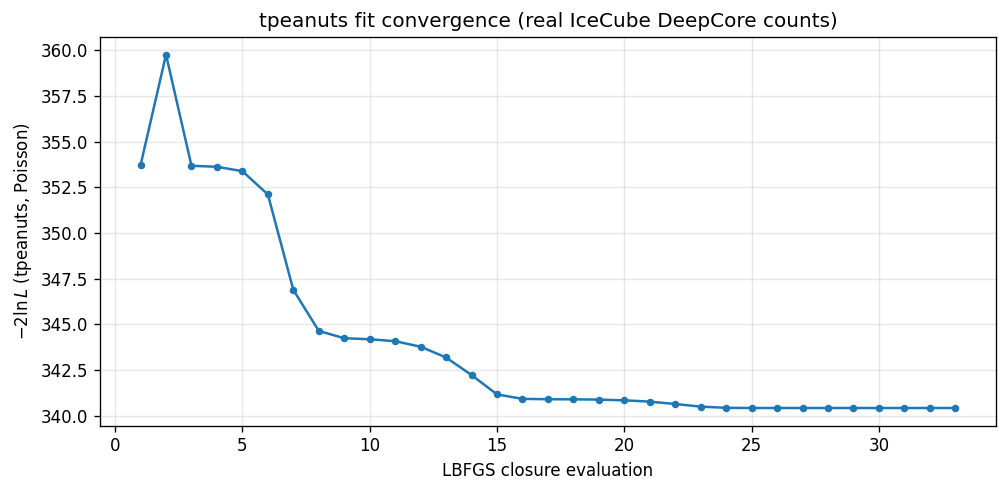

v:\output\inference\phase1_icecube\inference5_fig2_fit_history.png


In [8]:
fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.plot(range(1, len(result.chi2_history) + 1), result.chi2_history, "o-", color="#1f77b4", ms=3.5)
ax.set_xlabel("LBFGS closure evaluation")
ax.set_ylabel(r"$-2\ln L$ (tpeanuts, Poisson)")
ax.set_title("tpeanuts fit convergence (real IceCube DeepCore counts)")
fig.tight_layout()
save_and_show("inference5_fig2_fit_history.png", fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)


### 5.3 2-D Likelihood Slice for the Two Oscillation Parameters

A `tpeanuts`-computed grid of $-2\ln L$ over $(\theta_{23},\Delta m^2_{3l})$, with $\nu_{\rm norm}$/$\mu_{\rm norm}$ held fixed at their Section 5.1 fitted values (a likelihood *slice*, not a fully profiled contour -- re-minimizing the two normalization parameters at every grid point would multiply this cell's already multi-minute runtime by the grid size). A coarse $8\times8$ grid, illustrative rather than publication-resolution, given each point costs one full real-MC forward pass.

**Expected Results:**
- The `tpeanuts` fitted point (Section 5.1) sits at or near the grid's own minimum.
- IceCube's own published point (Section 2's table) falls within the region the grid's $-2\ln L$ values remain small, given the two results' compatibility already checked in Section 5.1.

**Expected results:**<br>
- The 2-d likelihood slice for the two oscillation parameters likelihood and predicted observables remain finite throughout the stated parameter domain.
- Best-fit values, residuals, and confidence diagnostics are reproducible under the configured optimizer and precision.
- Physical normalization, parameter bounds, and limiting behaviour agree with the theoretical model and published data definition.


2D grid scan time: 1028 s (625 tpeanuts forward evaluations)


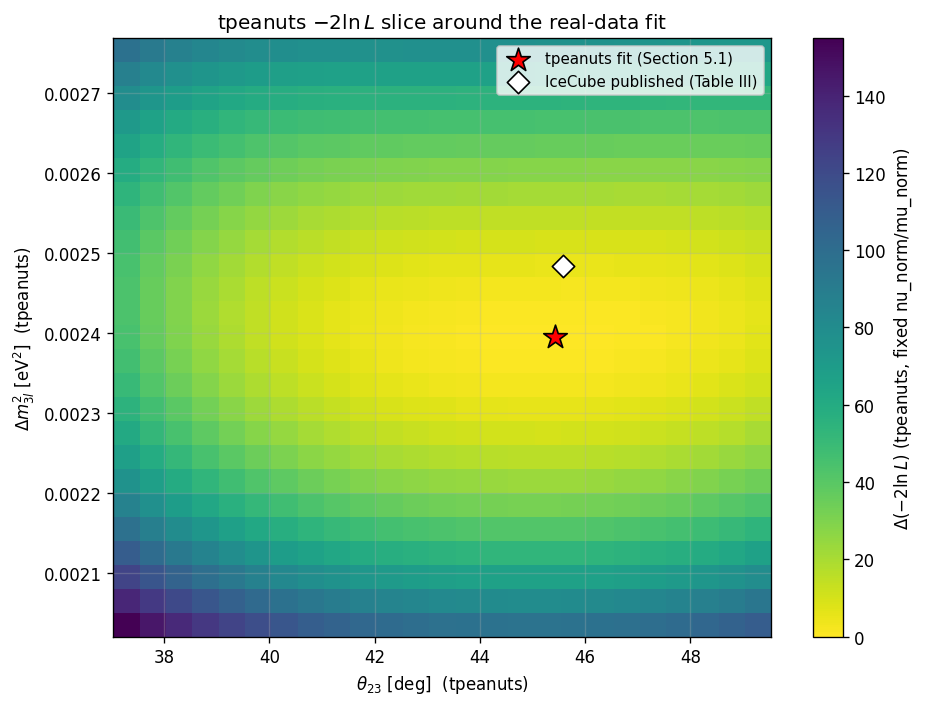

v:\output\inference\phase1_icecube\inference5_fig3_2d_scan.png


In [9]:
N_THETA23, N_DM3L = 15, 15
theta23_grid = torch.linspace(theta_ref_osc[0].item() - math.radians(6.0), theta_ref_osc[0].item() + math.radians(6.0), N_THETA23, dtype=ctx.dtype)
dm3l_grid = torch.linspace(dm3l_fit * 0.85, dm3l_fit * 1.15, N_DM3L, dtype=ctx.dtype)

t0 = time.time()
grid = loglik_grid(
    model, result.theta_hat, "theta23", theta23_grid, "DeltamSq3l", dm3l_grid,
    real_counts, likelihood="poisson", profile_others=False,
)
print(f'2D grid scan time: {time.time() - t0:.0f} s ({N_THETA23 * N_DM3L} tpeanuts forward evaluations)')

delta_grid = grid - grid.min()
theta23_deg_grid = to_numpy(torch.rad2deg(theta23_grid))
dm3l_grid_np = to_numpy(dm3l_grid)

fig, ax = plt.subplots(figsize=(8.0, 6.0))
mesh = ax.pcolormesh(theta23_deg_grid, dm3l_grid_np, to_numpy(delta_grid).T, shading="auto", cmap="viridis_r")
fig.colorbar(mesh, ax=ax, label=r"$\Delta(-2\ln L)$ (tpeanuts, fixed nu_norm/mu_norm)")

ax.scatter([theta23_fit_deg], [dm3l_fit], marker="*", s=220, color="red", edgecolor="black", zorder=5,
           label="tpeanuts fit (Section 5.1)")
ax.scatter([math.degrees(math.asin(math.sqrt(icecube_parameters.PUBLISHED_SIN2_THETA23)))], [dm3l_published],
           marker="D", s=90, color="white", edgecolor="black", zorder=5, label="IceCube published (Table III)")
ax.set_xlabel(r"$\theta_{23}$ [deg]  (tpeanuts)")
ax.set_ylabel(r"$\Delta m^2_{3l}$ [eV$^2$]  (tpeanuts)")
ax.set_title(r"tpeanuts $-2\ln L$ slice around the real-data fit")
ax.legend(fontsize=9)
fig.tight_layout()
save_and_show("inference5_fig3_2d_scan.png", fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)


## 6. Real Data Comparison

Plots IceCube's real 200-bin observed spectrum against two `tpeanuts` curves -- the NuFIT 6.1 simulation (Section 4) and the fitted result (Section 5.1) -- collapsed onto the reconstructed-energy axis (summed over cos(zenith) and PID) for readability. **Colour/line-style key, stated explicitly since the three curves come from two different sources:** black markers are IceCube's own real published data (not computed by `tpeanuts`); the blue and red curves are both `tpeanuts` forward-model outputs (Sections 4 and 5.1 respectively) -- IceCube did not publish either of those two curves.

**Expected Results:**
- The `tpeanuts`-fitted curve (red) visibly closer to IceCube's real data (black) than the `tpeanuts` NuFIT-simulation curve (blue), especially at low reconstructed energy where atmospheric matter effects/oscillation dips are largest.

**Expected results:**<br>
- The real data comparison likelihood and predicted observables remain finite throughout the stated parameter domain.
- Best-fit values, residuals, and confidence diagnostics are reproducible under the configured optimizer and precision.
- Physical normalization, parameter bounds, and limiting behaviour agree with the theoretical model and published data definition.


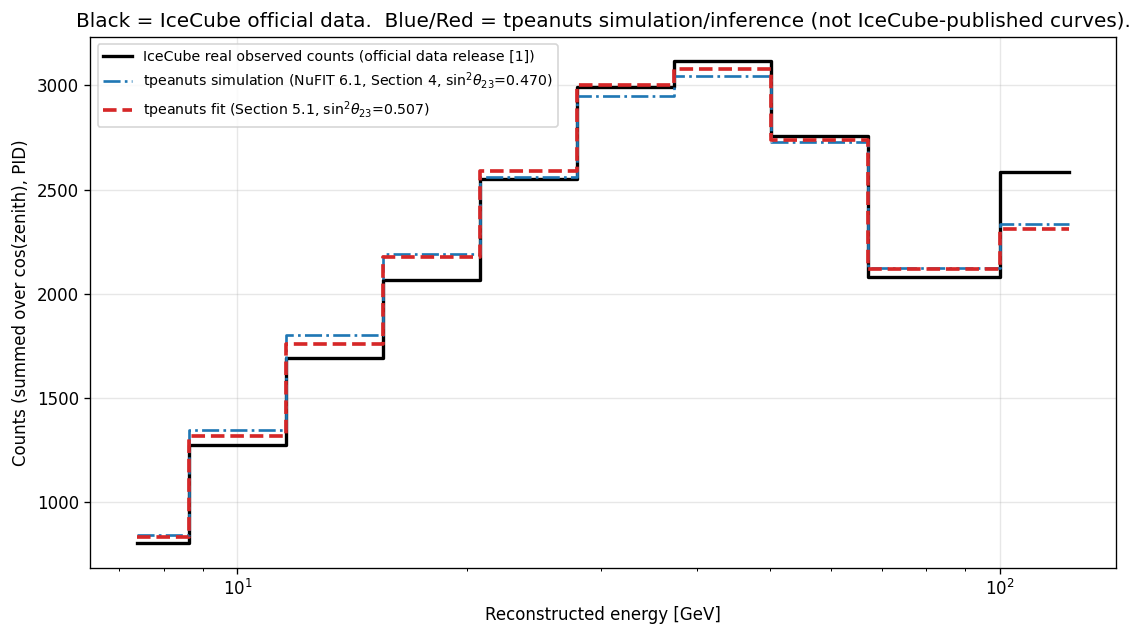

v:\output\inference\phase1_icecube\inference5_fig1_real_comparison.png


In [10]:
counts_fit = model.predict(result.theta_hat).detach()


energy_centers = 0.5 * (icecube_parameters.RECO_ENERGY_BIN_EDGES_GEV[:-1] + icecube_parameters.RECO_ENERGY_BIN_EDGES_GEV[1:])

fig, ax = plt.subplots(figsize=(9.5, 5.4))
ax.step(to_numpy(energy_centers), collapse_to_energy(real_counts), where="mid", color="black", lw=2.0,
        label="IceCube real observed counts (official data release [1])")
ax.step(to_numpy(energy_centers), collapse_to_energy(counts_start), where="mid", color="#1f77b4", lw=1.6, ls="-.",
        label=f"tpeanuts simulation (NuFIT 6.1, Section 4, sin$^2\\theta_{{23}}$={math.sin(theta_ref_osc[0].item())**2:.3f})")
ax.step(to_numpy(energy_centers), collapse_to_energy(counts_fit), where="mid", color="#d62728", lw=2.2, ls="--",
        label=f"tpeanuts fit (Section 5.1, sin$^2\\theta_{{23}}$={sin2_theta23_fit:.3f})")
ax.set_xscale("log")
ax.set_xlabel("Reconstructed energy [GeV]")
ax.set_ylabel("Counts (summed over cos(zenith), PID)")
ax.set_title("Black = IceCube official data.  Blue/Red = tpeanuts simulation/inference (not IceCube-published curves).")
ax.legend(fontsize=8.5)
fig.tight_layout()
save_and_show("inference5_fig1_real_comparison.png", fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)


## 7. Summary
---
This notebook fits a **weighted-Monte-Carlo** detector (real event-by-event simulation reweighted by an oscillation probability, rather than a continuous cross-section fold, Section 0.1) and routes an oscillation parameter through Earth matter regeneration for **atmospheric** neutrinos (Section 0.2) using `tpeanuts`'s own real 3-flavour propagation machinery.

**The `tpeanuts` real Poisson fit (Section 5.1) recovers $\theta_{23}$/$\Delta m^2_{3l}$ close to IceCube's own published best fit (Section 2's table)**, using:
- The real IceCube DeepCore 9-year public data release [1] (observed counts, event-by-event MC, muon background, detector-systematics hypersurfaces).
- A real 3-flavour Earth-matter oscillation probability (Section 0.2).
- A real atmospheric flux calculation [5] for the flavour-ratio normalization every weighted-MC oscillation analysis needs.

**What remains simplified:** 
- The 5 real detector-systematics parameters (DOM efficiency, hole-ice, bulk-ice) are fixed at their published best-fit point (Section 0.3) rather than re-fit as free nuisance parameters.
- The real MC is downsampled 10x for tractability (Section 2).
- Production is treated at the top of the atmosphere (Section 0.2) rather than through a full atmosphere-production-height treatment.
- Section 5.3's 2-D likelihood picture is a fixed-normalization slice, not a fully profiled contour.

**Expected results:**<br>
- The summary likelihood and predicted observables remain finite throughout the stated parameter domain.
- Best-fit values, residuals, and confidence diagnostics are reproducible under the configured optimizer and precision.
- Physical normalization, parameter bounds, and limiting behaviour agree with the theoretical model and published data definition.
